# 02 — CMIP6 Multi-Model Climate Projections

**The thesis of this notebook**: a single climate model's line is an opinion; the multi-model *range* is the finding.

> **CMIP6** — the Coupled Model Intercomparison Project, phase 6: a coordinated effort in which independent research groups worldwide run their own climate models over agreed scenarios, precisely so the models can be compared. Open-Meteo's Climate API serves a set of high-resolution (HighResMIP) runs on native grids of ~20–50 km, statistically downscaled to ~10 km before delivery.

> **Downscaling** — mapping coarse model output onto a finer grid. Open-Meteo does it statistically, using ERA5-Land as the fine-scale reference, not by running the models at a higher resolution.

> **Projection ≠ forecast** — a forecast starts from today's observed atmosphere and predicts specific weather. A projection is driven by *scenario* boundary conditions (greenhouse-gas trajectories) and makes no claim about any particular year: its year-to-year wiggles are internal model variability, not predictions. All projections here follow a single high-emission pathway (RCP8.5-like); Open-Meteo offers no scenario choice. Per Open-Meteo, scenarios differ little before 2050.

**Goal**: Exercise the client's multi-model parsing end-to-end, quality-check CMIP6 data per model, and quantify how much the models agree — and disagree — about the climate of two agricultural regions through 2050.

**Endpoint**: Climate API (CMIP6 projections, 1950–2050)

**Locations** (same two as [notebook 01](01-open-meteo-exploration.ipynb), for continuity):
- Pampa, Argentina (-34.6, -58.4) — major grain production region
- Midwest, USA (41.9, -89.1) — US corn belt

**Models** (the client's defaults):
- `EC_Earth3P_HR` — EC-Earth consortium (EU)
- `MRI_AGCM3_2_S` — Meteorological Research Institute (Japan)
- `FGOALS_f3_H` — Chinese Academy of Sciences

**How to read this notebook**: as in notebook 01, each section opens with what one would expect on physical grounds, then interprets what the data actually show. The canonical quality record lives in [`docs/data-quality-report.md`](../docs/data-quality-report.md).

**Data**: Climate data by [Open-Meteo.com](https://open-meteo.com/) (CC BY 4.0). We acknowledge the World Climate Research Programme's CMIP6 and the three modelling groups listed above ([Terms of Use](https://pcmdi.llnl.gov/CMIP6/TermsOfUse)). Contains modified Copernicus Climate Change Service information 2026. Full attribution in the [README](../README.md#data-licensing--attribution).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pretaverdi.analysis import hindcast_annual, inter_model_spread, mean_levels
from pretaverdi.client import get_climate_projections
from pretaverdi.plots import plot_bias
from pretaverdi.variables import CLIMATE_DEFAULT_MODELS, LOCATIONS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Fetch Projections — Three Models, One Request

We request 36 years (2015–2050) of daily projections for all three default models in a single call per location. The API returns one response message per model; the client assembles them into a frame with `(variable, model)` MultiIndex columns, verifying the returned model labels against the request.

*Reproducibility note*: these are large requests — Open-Meteo weighs calls by data volume, and a fresh run can hit the free tier's per-minute limit ("Minutely API request limit exceeded"). Wait a minute and re-run; responses are cached locally for 1 h.

In [2]:
MODELS = CLIMATE_DEFAULT_MODELS
START, END = "2015-01-01", "2050-12-31"

pampa = LOCATIONS["pampa_ar"]
proj_pampa = get_climate_projections(pampa["lat"], pampa["lon"], START, END)
print(f"Pampa shape: {proj_pampa.shape}")
proj_pampa.head()

Pampa shape: (13149, 9)


variable                  temperature_2m_max                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 03:00:00+00:00          26.291927     23.350990   26.756641   
2015-01-02 03:00:00+00:00          27.539232     25.456821   27.775154   
2015-01-03 03:00:00+00:00          27.986628     29.313959   26.038630   
2015-01-04 03:00:00+00:00          28.984024     28.721100   23.752108   
2015-01-05 03:00:00+00:00          29.381420     31.578238   25.065584   

variable                  temperature_2m_min                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 03:00:00+00:00          18.006268     22.842640   21.656164   
2015-01-02 03:00:00+00:00          18.905479     17.190125   20.632351   
2015-01-03 03:00:00+00:00          19.604902     21.236761   17.854511   
2015-01-04 03:00:00+00:00          20.004320     22.183392   18.626671   
2015-01-05 03:00:00+00:00          20.253744     22.830027   17.498831   

variable                  precipitation_sum                            
model                         EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H  
date                                                                   
2015-01-01 03:00:00+00:00               0.0      8.823085    0.602162  
2015-01-02 03:00:00+00:00               0.0      0.000000   59.419655  
2015-01-03 03:00:00+00:00               0.0      0.000000    0.000000  
2015-01-04 03:00:00+00:00               0.0      0.000000    0.000000  
2015-01-05 03:00:00+00:00               0.0      0.000000    0.000000

In [3]:
midwest = LOCATIONS["midwest_us"]
proj_midwest = get_climate_projections(midwest["lat"], midwest["lon"], START, END)
print(f"Midwest shape: {proj_midwest.shape}")
proj_midwest.head()

Midwest shape: (13149, 9)


variable                  temperature_2m_max                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 05:00:00+00:00          -0.114647      1.768735    1.534968   
2015-01-02 05:00:00+00:00           4.785588      3.933351    1.517399   
2015-01-03 05:00:00+00:00           3.985874      2.049012   -0.150496   
2015-01-04 05:00:00+00:00           5.236160     -0.735326    0.981609   
2015-01-05 05:00:00+00:00          10.786447      2.180337    0.713713   

variable                  temperature_2m_min                            \
model                          EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H   
date                                                                     
2015-01-01 05:00:00+00:00          -9.651465     -4.642940   -0.791112   
2015-01-02 05:00:00+00:00          -2.004561     -1.779431   -1.215542   
2015-01-03 05:00:00+00:00          -3.557615     -3.964112   -3.689734   
2015-01-04 05:00:00+00:00          -0.760669     -4.948793   -3.313925   
2015-01-05 05:00:00+00:00           4.236277     -4.933474   -2.588115   

variable                  precipitation_sum                            
model                         EC_Earth3P_HR MRI_AGCM3_2_S FGOALS_f3_H  
date                                                                   
2015-01-01 05:00:00+00:00          0.000000      0.000000    2.772555  
2015-01-02 05:00:00+00:00          0.172717      2.920825    0.213851  
2015-01-03 05:00:00+00:00          0.518593      0.291708    0.000000  
2015-01-04 05:00:00+00:00          1.643602      0.194225    0.000000  
2015-01-05 05:00:00+00:00         22.337177      0.096990    1.186762

Each frame is dates × (3 variables × 3 models). The MultiIndex makes ensemble operations one-liners: `proj_pampa["temperature_2m_max"]` selects a date × models frame, so row-wise `min`/`mean`/`max` across it *is* the model spread. A single-model call would return the flat shape of notebook 01.

## 2. Per-Model Quality Check

In multi-model data, *missingness is a per-model property*: each model is an independent dataset with its own coverage, so one model can silently lack a variable — or a stretch of years — that another provides. A quality check run on the frame as a whole would average the problem away, which is why we group every check by model. This may read as housekeeping; by §4 it will prove decisive for the conclusions themselves.

In [4]:
print(f"Rows per frame: {len(proj_pampa)} (daily, 2015–2050)")

ec_nan = proj_pampa[("temperature_2m_max", "EC_Earth3P_HR")].isna()
print(f"EC_Earth3P_HR NaN dates: {proj_pampa.index[ec_nan].min():%Y-%m-%d} "
      f"→ {proj_pampa.index[ec_nan].max():%Y-%m-%d} ({ec_nan.sum()} days)")

nulls = pd.concat(
    {"Pampa": proj_pampa.isna().mean(), "Midwest": proj_midwest.isna().mean()},
    axis=1,
).mul(100).round(1)
nulls.index.names = ["variable", "model"]
nulls.columns.name = "% NaN"
nulls

Rows per frame: 13149 (daily, 2015–2050)
EC_Earth3P_HR NaN dates: 2050-01-01 → 2050-12-31 (365 days)


% NaN                             Pampa  Midwest
variable           model                        
temperature_2m_max EC_Earth3P_HR    2.8      2.8
                   MRI_AGCM3_2_S    0.0      0.0
                   FGOALS_f3_H      0.0      0.0
temperature_2m_min EC_Earth3P_HR    2.8      2.8
                   MRI_AGCM3_2_S    0.0      0.0
                   FGOALS_f3_H      0.0      0.0
precipitation_sum  EC_Earth3P_HR    2.8      2.8
                   MRI_AGCM3_2_S    0.0      0.0
                   FGOALS_f3_H      0.0      0.0

The check earns its keep on its first table: `EC_Earth3P_HR` carries 2.8% NaN in *every* variable at both locations — exactly one year's worth, and the printed dates show why: its record simply ends in 2049, while the other two models run through 2050. Averaged over the ensemble this would have been invisible.

NaN is only the *explicit* form of missing, though. A subtler failure mode is missing data disguised as zeros — harmless in a temperature mean, catastrophic in a precipitation sum. A cheap plausibility floor: no year at either of these sites should total less than 300 mm.

In [5]:
def annual_precipitation(df):
    """Annual totals per model; partial years (<300 valid days) and
    implausibly dry years (<300 mm) are masked as missing."""
    annual = df["precipitation_sum"].resample("YE").sum(min_count=300)
    annual.index = annual.index.year
    return annual.mask(annual < 300)


for name, df in [("Pampa", proj_pampa), ("Midwest", proj_midwest)]:
    raw = df["precipitation_sum"].resample("YE").sum(min_count=300)
    raw.index = raw.index.year
    flagged = raw[(raw < 300).any(axis=1)]
    print(f"=== {name} — implausibly dry years (<300 mm), raw totals ===")
    print(flagged.round(0).to_string(), "\n")

fgoals_2016 = proj_pampa[("precipitation_sum", "FGOALS_f3_H")]["2016"]
print(f"FGOALS_f3_H 2016 at Pampa: {(fgoals_2016 == 0).sum()}/{len(fgoals_2016)} days are exactly 0 mm")

=== Pampa — implausibly dry years (<300 mm), raw totals ===
model  EC_Earth3P_HR  MRI_AGCM3_2_S  FGOALS_f3_H
date                                            
2016          1029.0         1145.0        160.0 

=== Midwest — implausibly dry years (<300 mm), raw totals ===
model  EC_Earth3P_HR  MRI_AGCM3_2_S  FGOALS_f3_H
date                                            
2016           891.0          890.0         31.0 

FGOALS_f3_H 2016 at Pampa: 350/366 days are exactly 0 mm


Caught: `FGOALS_f3_H`'s 2016 is zero on 350 of 366 days at *both* sites — annual totals of 160 mm (Pampa) and 31 mm (Midwest) that no NaN check would ever flag. `annual_precipitation()` treats such years as missing, and its `min_count` guard also handles `EC_Earth3P_HR`'s phantom 2050: summing an all-NaN year would otherwise return 0, not NaN. Every precipitation analysis below uses this cleaned form.

### 2.1 Exhibit: Why Soil Moisture Is Not a Default

A third, starker case of per-model missingness. We request `soil_moisture_0_to_10cm_mean` — the Climate API's daily soil band — for all three models over a single year.

In [6]:
soil = get_climate_projections(
    pampa["lat"], pampa["lon"], "2020-01-01", "2020-12-31",
    variables=["soil_moisture_0_to_10cm_mean"],
)
soil["soil_moisture_0_to_10cm_mean"].isna().mean().mul(100).round(1).rename("% NaN").to_frame()

,% NaN
model,
EC_Earth3P_HR,100.0
MRI_AGCM3_2_S,0.0
FGOALS_f3_H,100.0


Two of the three models return a 100% null series — and the API returns it *without any error*. An all-null series is indistinguishable from success unless you check. This is the concrete reason `CLIMATE_DEFAULTS` excludes soil moisture (see the comment in [`src/pretaverdi/variables.py`](../src/pretaverdi/variables.py) and the quality report), and the general lesson of this section: quality-check every model separately, because the ensemble hides per-model gaps.

## 3. The Key Figure: Multi-Model Temperature Spread

We aggregate daily values to *annual means* of (T max + T min) / 2 — climate being, in essence, the signal that survives once weather noise is averaged out. The figure's grammar: one thin line per model, and a shaded band spanning the per-year min–max across models. Under a shared warming scenario one would expect the models to agree on the *direction* of change while disagreeing on its *magnitude* — a visibly wide band that does not collapse over time, since each model resolves the same physics through different choices. In the figure, a dashed vertical line at 2024/25 separates the years that overlap the reanalysis record from the years that are projection only. How closely any of this tracks the observed record is a separate question, deferred to §5.

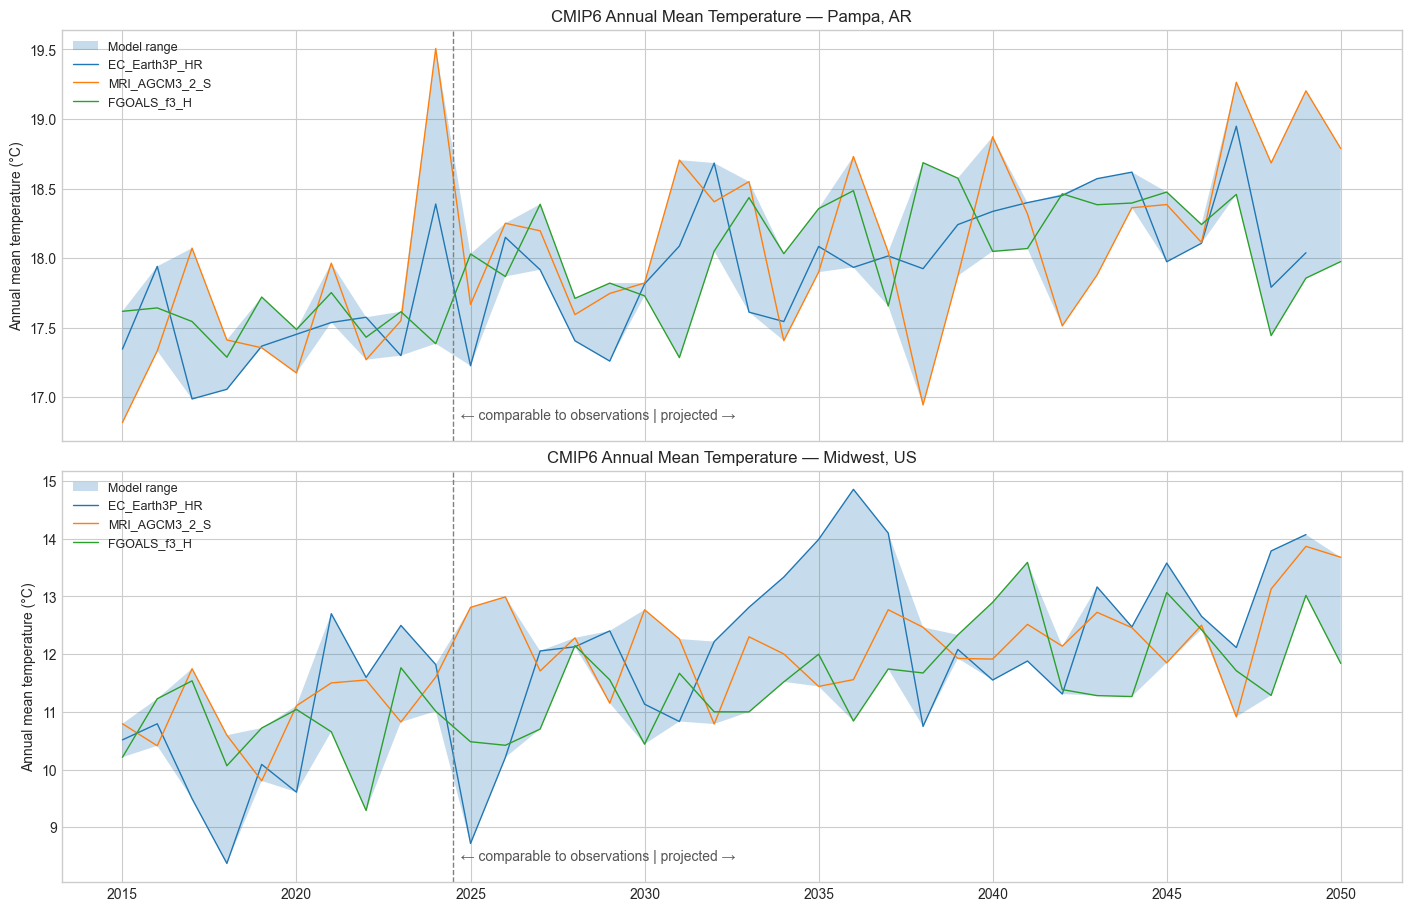

In [7]:
def annual_mean_temperature(df):
    """Annual mean of (tmax + tmin) / 2 per model, indexed by year."""
    tmean = (df["temperature_2m_max"] + df["temperature_2m_min"]) / 2
    annual = tmean.resample("YE").mean()
    annual.index = annual.index.year
    return annual


fig, axes = plt.subplots(2, 1, figsize=(14, 9), layout="constrained", sharex=True)

for ax, df, name in [(axes[0], proj_pampa, "Pampa, AR"), (axes[1], proj_midwest, "Midwest, US")]:
    annual = annual_mean_temperature(df)
    ax.fill_between(
        annual.index, annual.min(axis=1), annual.max(axis=1),
        alpha=0.25, label="Model range",
    )
    for model in MODELS:
        ax.plot(annual.index, annual[model], linewidth=1, label=model)
    ax.axvline(2024.5, color="gray", linestyle="--", linewidth=1)
    ax.text(2024.5, annual.min(axis=1).min(), "  ← comparable to observations | projected →",
            fontsize=10, color="#555", va="bottom")
    ax.set_ylabel("Annual mean temperature (°C)")
    ax.set_title(f"CMIP6 Annual Mean Temperature — {name}")
    ax.legend(loc="upper left", fontsize=9)

plt.show()

Direction unanimous, magnitude not: all three models warm both regions through 2050, with the Midwest warming roughly twice as fast as Pampa. The band stays visibly wide the whole way — that width is *structural* uncertainty: disagreement between equally defensible models given the same scenario. Two honest details. No single year on any line is a prediction (the wiggles are internal model variability). And §2's lesson is visible here: `EC_Earth3P_HR`'s line stops a year short — its record ends in 2049.

### 3.2 Precipitation Spread

Same grammar, annual *totals* this time — the cleaned totals from §2's `annual_precipitation()`, not raw sums. Here one would expect a messier picture: precipitation is where climate models disagree most, a canonical result of climate modeling. The *amount* of moisture in the air is thermodynamically constrained — warmer air holds about 7% more water vapour per °C, the Clausius–Clapeyron relation — but *where and when* that moisture falls depends on atmospheric circulation, and circulation is precisely what each model resolves differently.

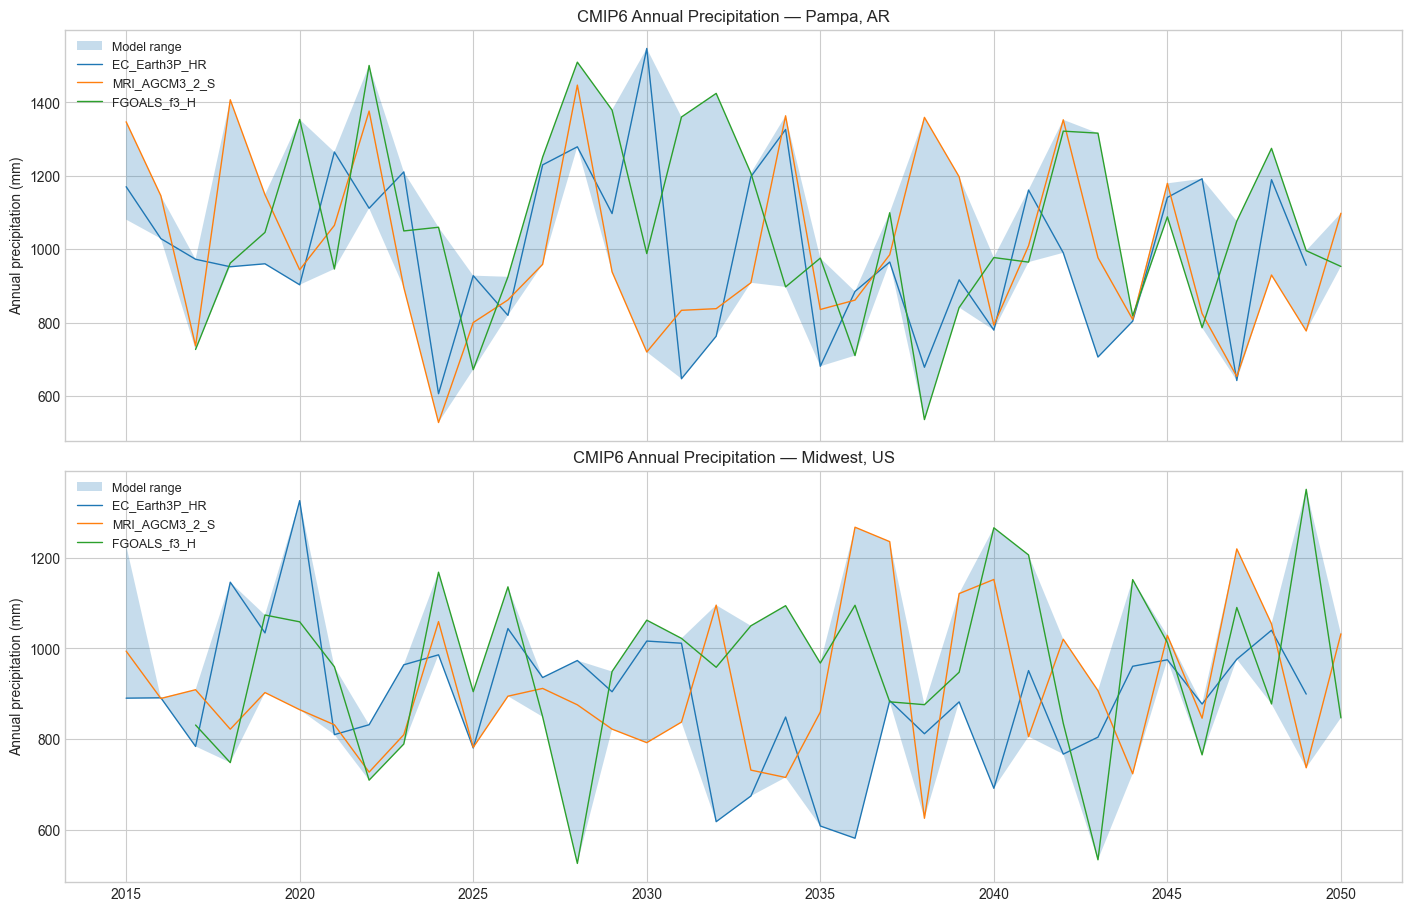

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), layout="constrained", sharex=True)

for ax, df, name in [(axes[0], proj_pampa, "Pampa, AR"), (axes[1], proj_midwest, "Midwest, US")]:
    annual = annual_precipitation(df)
    ax.fill_between(
        annual.index, annual.min(axis=1), annual.max(axis=1),
        alpha=0.25, label="Model range",
    )
    for model in MODELS:
        ax.plot(annual.index, annual[model], linewidth=1, label=model)
    ax.set_ylabel("Annual precipitation (mm)")
    ax.set_title(f"CMIP6 Annual Precipitation — {name}")
    ax.legend(loc="upper left", fontsize=9)

plt.show()

Messier, as predicted: the envelopes stay wide and overlapping across the whole window, and no model's line separates from the pack for long — where temperature showed a drift you can see, precipitation shows disagreement you can't miss. The two §2 artifacts are visible here as *gaps*, not lies: `EC_Earth3P_HR`'s line ends in 2049 and `FGOALS_f3_H`'s 2016 is masked out. Unmasked, both would have plotted as spikes to zero. The quantitative verdict comes next.

## 4. Quantifying Disagreement

The pictures suggest agreement on warming and disagreement on precipitation; now we put numbers on it. For each location and variable we compare two decades — 2015–2024 vs 2041–2050 — per model. The per-model *change* is the signal; the max−min across models' changes (the `spread` column) is the structural disagreement. When the spread is comparable to the signal, no single model's number deserves to be quoted alone.

In [9]:
def decadal_change(df, location):
    """Per-model change between the 2015-2024 and 2041-2050 decades."""
    rows = {}
    for label, annual in [
        ("t_mean (°C)", annual_mean_temperature(df)),
        ("precip (mm/yr)", annual_precipitation(df)),
    ]:
        early = annual[annual.index <= 2024].mean()
        late = annual[annual.index >= 2041].mean()
        delta = (late - early).round(1)
        rows[(location, label)] = {
            **delta.to_dict(),
            "spread": round(delta.max() - delta.min(), 1),
        }
    return rows


summary = pd.DataFrame.from_dict(
    {**decadal_change(proj_pampa, "Pampa"), **decadal_change(proj_midwest, "Midwest")},
    orient="index",
)
summary.index.names = ["location", "variable"]
summary

EC_Earth3P_HR  MRI_AGCM3_2_S  FGOALS_f3_H      spread
location variable                                                             
Pampa    t_mean (°C)          0.800000       0.800000          0.6    0.200000
         precip (mm/yr)     -42.200001     -98.400002        -21.0   77.400002
Midwest  t_mean (°C)          2.000000       1.600000          1.3    0.700000
         precip (mm/yr)     -49.599998      56.500000         15.4  106.099998

Temperature change is robust: Pampa warms +0.6 to +0.8 °C (a spread of 0.2 °C — about a quarter of the ensemble-mean warming), the Midwest +1.3 to +2.0 °C (spread 0.7 °C, over 40% of the ensemble-mean warming). Precipitation is where the thesis bites: at Pampa all three models lean dry (−21 to −98 mm/yr) but the spread (77 mm/yr) exceeds the central estimate, and at the Midwest the models do not even agree on the *sign* (−50 to +57 mm/yr, spread 106).

A meta-lesson, earned the hard way: computed on the **raw** data, this same table showed Pampa's models disagreeing in sign too — entirely an artifact of `FGOALS_f3_H`'s zero-2016 inflating its early-decade change (+71 instead of −21) and `EC_Earth3P_HR`'s phantom 2050 deflating its late decade (−140 instead of −42). Two data-quality fixes changed a qualitative conclusion. (Caveat that remains: `EC_Earth3P_HR`'s late decade is effectively 2041–2049.)

## 5. Hindcast: Models Compared with the Recent Past

**Question**

Do the models reproduce the temperature of a period that has already happened (2015–2024)?

> **Hindcast** — a model run over a past period, so that its output can be compared with the historical record.

**Reference**

ERA5-Land, a reanalysis with a resolution of about 10 km.

**What is compared**

- Only the mean temperature of the period.
- Individual years are not expected to match: these model runs do not start from observed conditions.

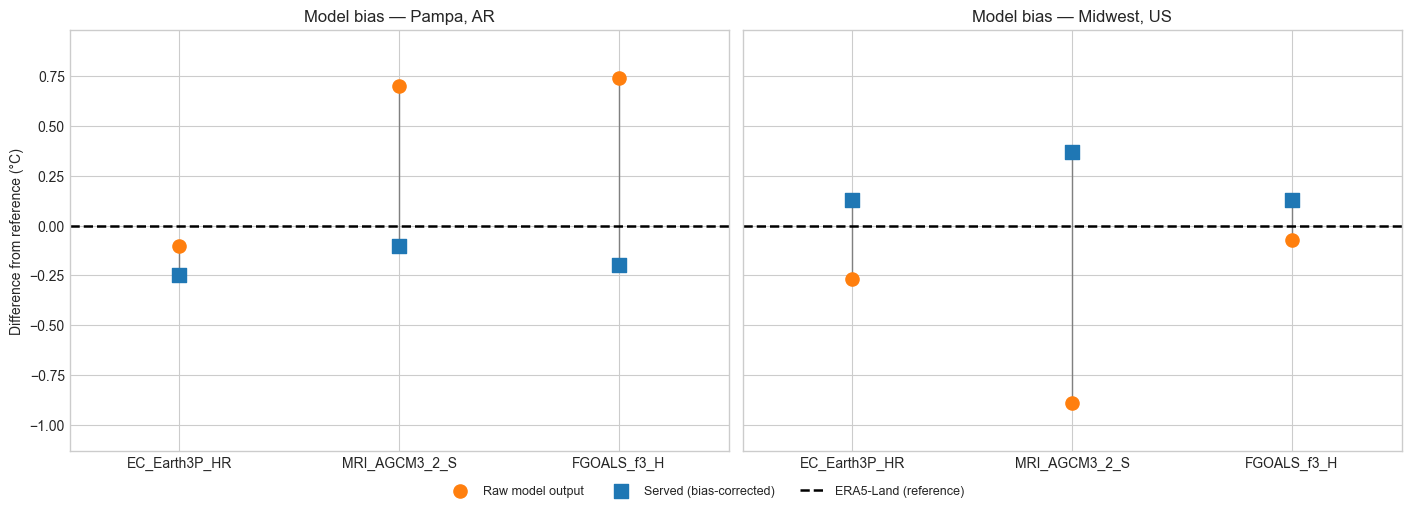

In [10]:
SITES = {"Pampa, AR": pampa, "Midwest, US": midwest}
hindcast = {site: hindcast_annual(loc) for site, loc in SITES.items()}
levels = pd.concat({site: mean_levels(annual) for site, annual in hindcast.items()}, names=["site"])
plot_bias(levels);

**Result**

- Raw model output: up to 0.9 °C from the reference, and the models do not agree on the direction.
- Served data: within 0.4 °C of the reference for every model.

**Reason**

- Open-Meteo corrects each model towards ERA5-Land before serving it ([documentation](https://open-meteo.com/en/docs/climate-api)).
- The close agreement is a result of this correction. It is not a measure of model quality.

> **Bias** — a systematic difference between a model and a reference.

> **Bias correction** — an adjustment that removes this difference.

In [11]:
levels

raw  served  reference  raw − ref  served − ref
site        model                                                           
Pampa, AR   EC_Earth3P_HR  17.64   17.49      17.74      -0.10         -0.25
            MRI_AGCM3_2_S  18.45   17.64      17.74       0.70         -0.10
            FGOALS_f3_H    18.49   17.55      17.74       0.74         -0.20
Midwest, US EC_Earth3P_HR  10.35   10.75      10.62      -0.27          0.13
            MRI_AGCM3_2_S   9.73   10.99      10.62      -0.89          0.37
            FGOALS_f3_H    10.55   10.75      10.62      -0.07          0.13

**Values**

- `raw`, `served` and `reference`: mean temperature for 2015–2024, in °C.
- `raw − ref` and `served − ref`: difference from the reference.

In [12]:
inter_model_spread(levels)

,raw,served
site,,
"Pampa, AR",0.85,0.15
"Midwest, US",0.82,0.24


**Result**

- Before correction, the models differ from each other by about 0.8 °C.
- After correction, by about 0.2 °C.

**Conclusions**

- The served data hides most of the disagreement between models on temperature *levels*.
- It does not hide the disagreement on temperature *change* (§4). According to Open-Meteo, the correction does not affect the climate change signal.
- Indicators based on absolute thresholds (frost, heat stress) can use the served data. The correction is made by the provider and assumes that each model's bias stays constant in the future.

## 6. Findings & Limitations

### Findings
- **Multi-model parsing works end-to-end**: one 36-year request per location returns all three models, labeled via the response metadata and shape-verified, as `(variable, model)` columns.
- **Even "complete" models differ in temporal coverage**: `EC_Earth3P_HR` ends in 2049 — a full year of NaNs (2.8% of the window) that only a per-model check catches.
- **Missingness can be disguised as zeros**: `FGOALS_f3_H`'s 2016 is 350/366 zero-precipitation days at both sites (annual totals of 160 mm and 31 mm) — invisible to NaN checks, caught by a plausibility floor, masked in every analysis here.
- **Soil moisture reproduces its documented gap**: 100% null for `EC_Earth3P_HR` and `FGOALS_f3_H`, full data for `MRI_AGCM3_2_S` — and the API returns the null series without error.
- **Warming is robust, precipitation is not**: temperature change agrees in sign and roughly in magnitude at both sites (inter-model spread about 25–45% of the ensemble-mean warming); cleaned precipitation change leans dry at Pampa (−21 to −98 mm/yr) but disagrees *in sign* at the Midwest (−50 to +57 mm/yr), with spreads comparable to or exceeding the signal.
- **Data quality changes conclusions**: on raw data, the decadal table showed sign disagreement at Pampa too — created entirely by the two coverage artifacts above.
- **Agreement with reanalysis comes from the provider's bias correction**: raw, the models sit −0.89 to +0.74 °C from ERA5-Land and up to 0.85 °C from each other; Open-Meteo's bias correction brings the served data within −0.25 to +0.37 °C and the inter-model spread down to 0.15–0.24 °C (2015–2024).

### Limitations
- Open-Meteo serves **one downscaling chain and one scenario** per model (a single high-emission pathway, RCP8.5-like) — this is a slice of CMIP6, not the full ensemble; the true structural uncertainty is wider than shown here
- **Mixed experiment designs** — `MRI_AGCM3_2_S` is an atmosphere-only model, run with prescribed sea-surface temperatures; HighResMIP catalogues list the same design for `FGOALS_f3_H`, while `EC_Earth3P_HR` is a coupled model. Open-Meteo does not state which experiment it serves per model, so the model range is not a clean structural spread
- **Three models is a small sample** of model diversity; the min–max band is a floor on the uncertainty, not a confidence interval
- Served at ~10 km, downscaled from ~20–50 km native model grids — regional averages only, no field-level signal
- **Annual means hide extremes** — heat waves, frosts and dry spells matter more to agriculture than the mean, and need daily-scale indicators
- **No *additional* bias correction applied** — the served data is already downscaled and bias-corrected upstream by Open-Meteo against ERA5-Land; that correction assumes each model's bias stays stable into the future, an assumption this notebook does not test

### Decision Gate

**Decision: risk-indicator prototyping must consume the ensemble *range*, never a single model's trajectory.**

The warming signal is robust across models at both sites while precipitation is not, and the models' level agreement with reanalysis is largely a result of the provider's bias correction (§5). The next step is therefore to prototype risk indicators (building on notebook 01's water-balance conclusion) that propagate the model range end-to-end — and to extend the quality assessment to the remaining reference regions (Punjab, Central Kenya).

---

*The canonical quality record lives in [`docs/data-quality-report.md`](../docs/data-quality-report.md). Previous chapter: [`01-open-meteo-exploration.ipynb`](01-open-meteo-exploration.ipynb).*